In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import math

# Maps of random walks on complex networks reveal community structure

This notebook reproduces results from the seminal paper by [M. Rosvall and C. T. Bergstrom, 2007](https://doi.org/10.48550/arXiv.0707.0609), which introduced the concept of using information flow in networks to optimally group nodes into well-connected modules. The approach leverages random walks on the network and uses their entropy as a proxy for identifying large-scale structures (modules). This idea is rooted in Shannon's source coding theorem, where the entropy of a random variable $H[X]$ (here, a random walk) provides a lower bound for the average codeword length. Huffman coding achieves this by assigning longer codewords to less likely outcomes.

The authors extend this concept by considering the network's structure: they propose a two-level description, assigning unique names to modules and reusing node names within each module. This strategy significantly reduces description length compared to a single-level approach.

Our goal is to express the average description length as a function of a module partition $M$ for a network with $n$ nodes and $m$ modules. This leads to the **map equation**:

$$
L(M) = \left(\sum_i^m q_{i\curvearrowright}\right) \log\left(\sum_i^m q_{i\curvearrowright}\right)  - 2 \sum_i^m q_{i\curvearrowright} \log(q_{i\curvearrowright}) + \sum_i^m \left(q_{i\curvearrowright} + \sum_{\alpha \in i} p_\alpha\right) \log\left(q_{i\curvearrowright} + \sum_{\alpha \in i} p_\alpha\right) + H[p_\alpha]
$$

Here, $q_{i\curvearrowright}$ is the probability per step that a random walker switches modules, and $p_\alpha$ is the visit frequency of node $\alpha$. By minimizing $L(M)$, we find the optimal community structure (partition $M^*$) that reduces the average description length and reveals regularities in the network's structure:

$$M^*=\arg\min_M L(M)$$

## Computing the map equation

To compute the map equation, two key ingredients are required: the ergodic node visit frequency $p_\alpha$ for each node $\alpha$, and the probability that a random walker exits a module.

- **Node visit frequency $p_\alpha$**:  
    The probability that a node $\alpha$ is visited by a random walker is determined by the stationary distribution of a Markov chain defined by the network's adjacency matrix $A$. However, real-world networks may not be ergodic, so to ensure a unique steady-state distribution $\pi_{\mathrm{stat}}$, a small teleportation probability $\tau$ is introduced. This allows the walker to jump to any node at random, making the chain irreducible and aperiodic. The transition matrix is:
    $$
    \mathcal{P} = \frac{\tau}{n}(\mathbb{1}\mathbb{1}^T) + (1-\tau)A
    $$
    By the Perron-Frobenius theorem, this guarantees a unique stationary distribution, which can be computed via the power method or by finding the eigenvector with eigenvalue $\lambda=1$. This approach is similar to the **PageRank** algorithm (which has $\tau=0.15$), efficiently implemented in the `networkx` Python library.

- **Module exit probabilities**:  
    Given the node visit frequencies $p_\alpha$ and a partition $M$ of the network, the probability of exiting module $i$ is the sum of all ways a walker can leave the module: either by teleportation or by traversing an edge to another module:
    $$
    q_{i\curvearrowright} = \tau \frac{n-n_i}{n-1} \sum_{\alpha \in i} p_\alpha + (1-\tau) \sum_{\alpha \in i} \sum_{\beta \notin i} p_\alpha w_{\alpha\beta}
    $$
    where $n_i$ is the number of nodes in module $i$, and $w_{\alpha\beta}$ is the weight of the edge from $\alpha$ to $\beta$.

In [62]:
# ==============================
# ===== CODICE DI LORENZO ======
# ==============================

def shannonEntropy(probabilities):
    h = 0
    for p in probabilities:
        if p > 0:
            h -= p * math.log2(p)
    return h

def mapEquation(G, partition, equilibriumProbabilities, tau=0.15):
    # dict containing the modules
    modules = set(partition.values())
    n = G.number_of_nodes()
    q_out = {m: 0.0 for m in modules}  # q_i for each module
    p_sum = {m: 0.0 for m in modules}  # \sum_\alpha \in i p_\alpha for each i
    mod_nodes = {m: [] for m in modules} # List of nodes in each module

    # Let's populate these dicts
    for u in G.nodes():
        # Module of node u
        m_u = partition[u]
        # Its equilibrium probability
        pr_u = equilibriumProbabilities[u]
        
        p_sum[m_u] += pr_u
        mod_nodes[m_u].append(u)
        
        deg_u = G.degree(u, weight='weight')
        if deg_u > 0:
            for v in G.neighbors(u):
                m_v = partition[v]
                if m_u != m_v: 
                    # Get the weight of the edge (u, v), if one is there, otherwise default to 1
                    w_uv = G[u][v].get('weight', 1.0)
                    # Using the formula in the paper 
                    q_out[m_u] += (1-tau)*(pr_u / deg_u) * w_uv 
    for m in modules:
        n_i = len(mod_nodes[m]) 
        teleport_flow = tau * (n - n_i) / (n - 1) * p_sum[m]
        q_out[m] += teleport_flow

    # Now let's compute the first term for the map equation
    total_q = sum(q_out.values())
    if total_q < 1e-12:   # regularization to avoid log(0), 0 log(0) = 0
        L_index = 0.0
    else:
        Q_probs = [val / total_q for val in q_out.values()]
        L_index = total_q * shannonEntropy(Q_probs)

    # Computing the second term for the map equation
    L_module = 0.0
    for m in modules:
        p_circle = p_sum[m] + q_out[m]
        
        if p_circle > 1e-12:
            probs_internal = [equilibriumProbabilities[u] / p_circle for u in mod_nodes[m]]
            probs_internal.append(q_out[m] / p_circle)
            L_module += p_circle * shannonEntropy(probs_internal)
            
    return L_index + L_module

# Helper function to draw the graph with a partition
def draw_partition(G, partition_dict, title):
    pos = nx.spring_layout(G, seed=42)
    node_colors = [partition_dict[n] for n in G.nodes()]

    plt.figure(figsize=(10, 7))
    plt.title(title)
    nx.draw(G, pos, with_labels=True, node_color=node_colors, cmap=plt.cm.tab10, node_size=500, edge_color="gray", font_color="black")
    plt.show()

## Finding the optimal partition $M^*$

Minimizing the map equation to find the optimal community structure is a challenging computational problem. Exhaustively evaluating all possible partitions is infeasible for all but the smallest networks. Instead, Rosvall and Bergstrom propose a two-step heuristic approach combining greedy search and simulated annealing:

1. **Greedy Search**:  
    - Start with each node in its own module ($m = n$).
    - At each step, consider all possible pairs of modules and evaluate the effect of merging them on the map equation $L(M)$.
    - Select the merge that yields the largest decrease in $L(M)$.
    - Repeat this process until no further merge reduces $L(M)$.

2. **Simulated Annealing**:  
    - To escape local minima found by the greedy search, apply simulated annealing.
    - Randomly propose moves where a node is reassigned to a different module.
    - Accept moves according to the Metropolis criterion, using either the Boltzmann factor $A_{ij} = \min(1, e^{-\Delta L_{ij}/T})$ or, as suggested in the paper, the heat bath acceptance $A_{ij} = 1/(1 + e^{\Delta L_{ij}/T})$ (Fermi distribution), which is often more efficient.
    - Begin with a high temperature $T$ to allow exploration of higher-$L$ states, then gradually reduce $T$ according to a cooling schedule, favoring moves that decrease $L$.
    - Repeat the annealing process multiple times with slightly different initial temperatures, keeping the partition $M^*$ with the lowest observed $L(M)$.

A key insight is that we do not need to compute the absolute value of $L$ for every partition; it is sufficient to evaluate the change in description length $\Delta L$ resulting from a proposed merge or move. This allows for efficient updates, as only the affected modules' contributions to $L$ need to be recalculated.


In [86]:
def nodeProbabilities(G : nx.Graph, tau: float = 0.15, method: str = 'pagerank', tol : float = 1e-6, max_iter : int = 1000) -> list:
    """
    Compute the stationary probabilities of a random walk with teleportation on the graph G.
    
    Parameters:
    ----------
    G : nx.Graph
        The input graph for which we want to compute the stationary probabilities.
    tau : float, optional
        The teleportation probability for the random walk. Default is 0.15.
    method : str, optional
        The method to compute the stationary probabilities. Choose from 'powerMethod', 'pagerank', or 'eigenvector'. Default is 'pagerank'.
    tol : float, optional
        The tolerance for convergence in the power method. Default is 1e-6.
    max_iter : int, optional
        The maximum number of iterations for the power method. Default is 1000.
        
    Returns:
    -------
    list
        A list of stationary probabilities for each node in the graph.
    """
    if method not in ['powerMethod', 'pagerank', 'eigenvector']:
        raise ValueError("Invalid method. Choose from 'powerMethod', 'pagerank', or 'eigenvector'.")
    
    # Normalize rows to get transition probabilities
    A = nx.to_numpy_array(G, weight='weight')
    A = A / A.sum(axis=1, keepdims=True)  
    n = A.shape[0]

    # Add teleportation
    P = (1 - tau) * A + tau / n * np.ones((n, n))

    if method == 'powerMethod':
        p = np.ones(n) / n  # Start with uniform distribution
        for _ in range(max_iter):
            p_new = p @ P
            if np.linalg.norm(p_new - p, ord=1) < tol: return p_new.tolist()
            p = p_new
        raise ValueError(f"Power method did not converge within the maximum number of iterations max_iter={max_iter}.")

    if method == 'pagerank':
        return list(nx.pagerank(G, alpha=1-tau).values())

    if method == 'eigenvector':
        from scipy.sparse.linalg import eigs
        vals, vecs = eigs(P.T, k=1, which='LM')
        stationary = np.real(vecs[:, 0])
        stationary /= stationary.sum()  # Normalize to sum to 1
        return stationary.tolist()          


def greedyMerge(G: nx.Graph, partition: dict = None, equilibriumProbabilities: list = None,
                 tau: float = 0.15, n_iter: int = 100, tol: float = 1e-6, save_history: bool = False, verbose: bool = False):
    """
    Greedy merge algorithm for community detection based on the map equation. Computational complexity O(n^2)
    > M. Rosvall and C. T. Bergstrom, "Maps of random walks on complex networks reveal community structure", 2008.

    Parameters:
    ----------
    G : nx.Graph
        The input graph for which we want to find the community structure.
    partition : dict, optional
        A dictionary mapping each node to its initial module. If None, each node starts in its own module.
    equilibriumProbabilities : list, optional
        A list of stationary probabilities for each node. If None, it will be computed using PageRank.
    tau : float, optional
        The teleportation probability for the random walk. Default is 0.15.
    n_iter : int, optional
        The number of iterations for the greedy merge process. Default is 100.
    tol : float, optional
        The tolerance for convergence. If the improvement in L is less than tol, the algorithm will stop. Default is 1e-6.
    save_history : bool, optional
        Whether to save the history of L values during the merging process. Default is False.
    verbose : bool, optional
        Whether to print verbose output during the merging process. Default is False.
        
    Returns:
    -------
    dict
        A dictionary mapping each node to its final module after the greedy merge process.
    list (optional)
        If save_history is True, returns a list of L values at each step of the merging process.
    """
    # Initialize partitions if not provided
    if partition is None:
        partition = {u: u for u in G.nodes()}
    else:
        partition = partition.copy()

    # Compute stationary probabilities if not provided
    if equilibriumProbabilities is None:
        equilibriumProbabilities = list(nx.pagerank(G).values())

    L_values = []
    current_L = mapEquation(G, partition, equilibriumProbabilities, tau)
    L_values.append(current_L)

    best_partition = partition

    for iter in range(n_iter):
        modules = list(set(best_partition.values()))
        np.random.shuffle(modules)
        if len(modules) <= 1:
            break

        if verbose:
            print(f"Iteration {iter + 1}/{n_iter}, current L = {current_L:.6f}, modules = {len(modules)}")

        best_L = current_L
        best_merge = None 

        # Try all pairs of modules
        for i in modules:
            m_i = i
            for j in modules:
                if j == m_i:
                    continue
                m_j = j

                # Merge module m_j into m_i
                trial_partition = best_partition.copy()
                for node, mod in best_partition.items():
                    if mod == m_j:
                        trial_partition[node] = m_i

                L_new = mapEquation(G, trial_partition, equilibriumProbabilities, tau)
                if L_new < best_L:
                    best_L = L_new
                    best_merge = (m_i, m_j)

        # Stop if no improving merge was found
        if best_merge is None or (current_L - best_L) < tol:
            break

        # Apply best merge
        keep_m, merge_m = best_merge
        for node, mod in list(best_partition.items()):
            if mod == merge_m:
                best_partition[node] = keep_m

        current_L = best_L
        L_values.append(current_L)

    if save_history:
        return best_partition, L_values
    return best_partition

def simulatedAnnealing(G : nx.Graph, partition : dict, equilibriumProbabilities : list = None, tau : float = 0.15, n_iter : int = None,
                       T_max : float = 1.0, T_min : float = 1e-3, cooling_rate : float = 0.99, save_history : bool = False):
    """  
    Simulated annealing algorithm for community detection based on the map equation.
    > M. Rosvall and C. T. Bergstrom, "Maps of random walks on complex networks reveal community structure", 2008.

    Parameters:
    ----------
    G : nx.Graph
        The input graph for which we want to find the community structure.
    partition : dict
        A dictionary mapping each node to its initial module.
    equilibriumProbabilities : list
        A list of stationary probabilities for each node.
    tau : float, optional
        The teleportation probability for the random walk. Default is 0.15.
    n_iter : int, optional
        The number of iterations for the simulated annealing process. If None, it will be set to the number of nodes in the graph. Default is None.
    T_max : float, optional
        The initial temperature for the simulated annealing process. Default is 1.0.
    T_min : float, optional
        The minimum temperature for the simulated annealing process. Default is 1e-3.
    cooling_rate : float, optional
        The cooling rate for the simulated annealing process. Default is 0.99.
    save_history : bool, optional
        Whether to save the history of L values during the merging process. Default is False.
    
    Returns:
    -------
    dict
        A dictionary mapping each node to its final module after the simulated annealing process.
    list (optional)
        If save_history is True, returns a list of L values at each step of the merging process.
    """
    
    # Compute probabilities if not provided
    if equilibriumProbabilities is None:
        equilibriumProbabilities = list(nx.pagerank(G).values())

    if n_iter is None:
        n_iter = G.number_of_nodes()

    L_values = []
    current_partition = partition.copy()
    current_L = mapEquation(G, current_partition, equilibriumProbabilities, tau)

    best_partition = current_partition.copy()
    best_L = current_L
    if save_history: L_values.append(current_L)

    T = T_max
    while T > T_min:
        for _ in range(n_iter):
            # Pick a random node u and its neighbor v
            u = np.random.choice(list(G.nodes()))
            neighbors = list(G.neighbors(u))
            if not neighbors:
                continue
            
            # Move u to the module of a random neighbor v or 
            # to a random node in the whole network
            v = np.random.choice(list(neighbors))
            #v = np.random.choice(list(G.nodes()))

            # Check if the neighbor u belongs to a different module
            target_module = current_partition[v]
            current_module = current_partition[u]
            if current_module == target_module:
                continue
            
            trial_partition = current_partition.copy()
            trial_partition[u] = target_module
            trial_L = mapEquation(G, trial_partition, equilibriumProbabilities, tau)
            delta_L = trial_L - current_L

            # Accept or reject the move based on the Metropolis criterion
            if delta_L < 0 or np.random.rand() < 1 / (1 + math.exp(delta_L / T)):
                current_partition = trial_partition
                current_L = trial_L

                if current_L < best_L:
                    best_L = current_L
                    best_partition = current_partition.copy()
        
        if save_history: L_values.append(current_L)
        T *= cooling_rate
        
    if save_history: return best_partition, current_partition, L_values
    return best_partition


def coolingCycles(G : nx.Graph, partition : dict, equilibriumProbabilities : list, tau : float = 0.15, 
                  cooling_cycles : int = 5, save_history : bool = False, verbose : bool = False,
                  T_max : float = 1.0, T_min : float = 1e-3, cooling_rate : float = 0.99, n_iter : int = None):
    """ Performs multiple cooling cycles of simulated annealing to refine the community structure found by the greedy merge algorithm.
    
    Parameters:
    ----------
    G : nx.Graph
        The input graph for which we want to find the community structure.
    partition : dict
        A dictionary mapping each node to its initial module, typically the output of the greedy merge algorithm.
    equilibriumProbabilities : list
        A list of stationary probabilities for each node.
    tau : float, optional
        The teleportation probability for the random walk. Default is 0.15.
    cooling_cycles : int, optional
        The number of cooling cycles to perform. Default is 5.
    save_history : bool, optional
        Whether to save the history of L values during the cooling cycles. Default is False.
    T_max : float, optional
        The initial temperature for the simulated annealing process in each cooling cycle. Default is 1.0.
    T_min : float, optional
        The minimum temperature for the simulated annealing process in each cooling cycle. Default is 1e-3.
    cooling_rate : float, optional
        The cooling rate for the simulated annealing process in each cooling cycle. Default is 0.99.
    n_iter : int, optional
        The number of iterations for the simulated annealing process in each cooling cycle. If None, it will be set to the number of nodes in the graph. Default is None.
    verbose : bool, optional
        Whether to print verbose output during the cooling cycles. Default is False.
        
    Returns:
    -------
    dict
        A dictionary mapping each node to its final module after the cooling cycles.
    list (optional)
        If save_history is True, returns a list of L values at each step of the cooling cycles.
    """
    
    if n_iter is None:
        n_iter = G.number_of_nodes()

    best_partition = partition.copy()
    best_L = mapEquation(G, best_partition, equilibriumProbabilities, tau)
    L_history_sa = []

    for cycle in range(cooling_cycles):
        current_T_max = T_max * (1.0 + np.random.uniform(-0.5, 0.5))
        if verbose:
            print(f"Starting cycle {cycle + 1}/{cooling_cycles} with T_max = {current_T_max:.4f}")
        final_partition, _, _L = simulatedAnnealing(G, best_partition, equilibriumProbabilities, tau=tau, 
                                            n_iter=n_iter, T_max=current_T_max, T_min=T_min, cooling_rate=cooling_rate, save_history=True)
        if save_history: L_history_sa.extend(_L)
        L_current = mapEquation(G, final_partition, equilibriumProbabilities, tau)

        if L_current < best_L:
            if verbose:
                print(f"    Improved L from {best_L:.4f} to {L_current:.4f}")
            best_L = L_current
            best_partition = final_partition
        
    if save_history: return best_partition, L_history_sa
    return best_partition

### Example: Zachary's karate club

Final partitions: m = 3
After greedy search: L = 4.4563 bits


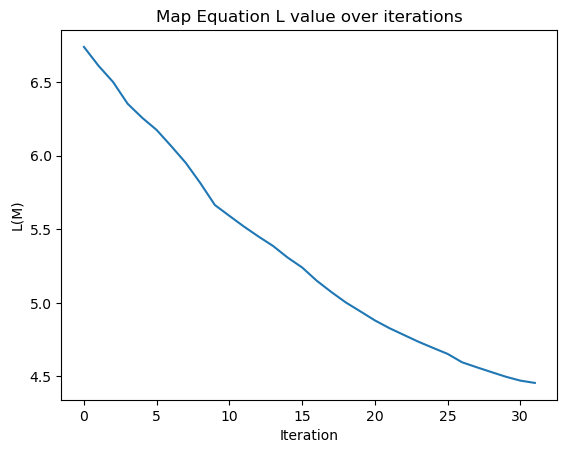

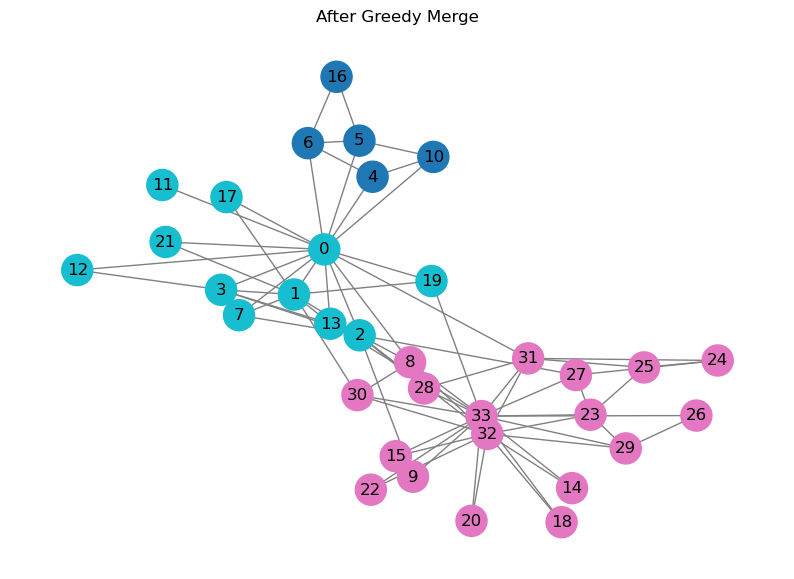

Final partitions: m = 3
After simulated annealing: L = 4.4563 bits


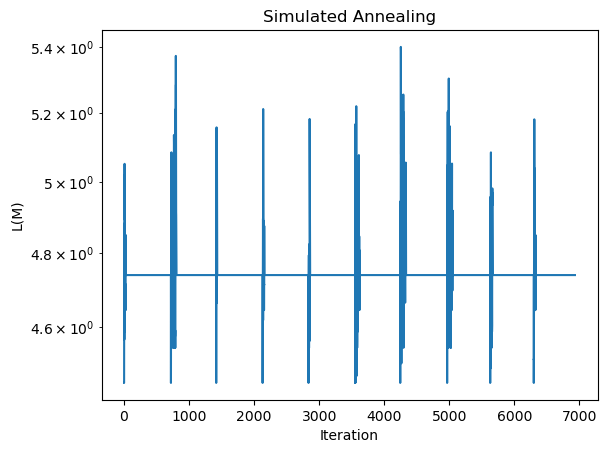

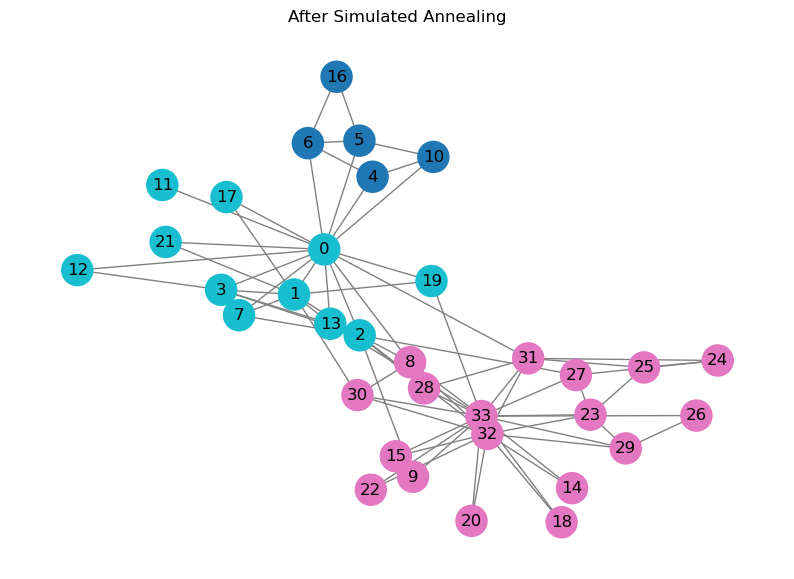

In [66]:
G = nx.karate_club_graph()
#G = nx.gaussian_random_partition_graph(n = 50, s = 15, v = 3, p_in = 0.7, p_out = 0.05, seed=123)
greedy_partition, L_history = greedyMerge(G, n_iter=100, save_history=True)

print("Final partitions: m =", len(set(greedy_partition.values())))
print(f"After greedy search: L = {L_history[-1]:.4f} bits")

plt.plot(L_history)
plt.xlabel('Iteration')
plt.ylabel('L(M)')
plt.title('Map Equation L value over iterations')
plt.show()

draw_partition(G, greedy_partition, title="After Greedy Merge")

probs = list(nx.pagerank(G).values())
final_partition, L_history_sa = coolingCycles(G, greedy_partition, probs, tau=0.15, cooling_cycles=10, save_history=True, T_min=1e-3)

print("Final partitions: m =", len(set(final_partition.values())))
print(f"After simulated annealing: L = {mapEquation(G, final_partition, probs, tau=0.15):.4f} bits")

plt.plot(L_history_sa)
plt.xlabel('Iteration')
plt.ylabel('L(M)')
plt.title('Simulated Annealing')
plt.yscale('log')
plt.show()

draw_partition(G, final_partition, title="After Simulated Annealing")

### Example: 

Final partitions: m = 15
After greedy search: L = 6.2852 bits


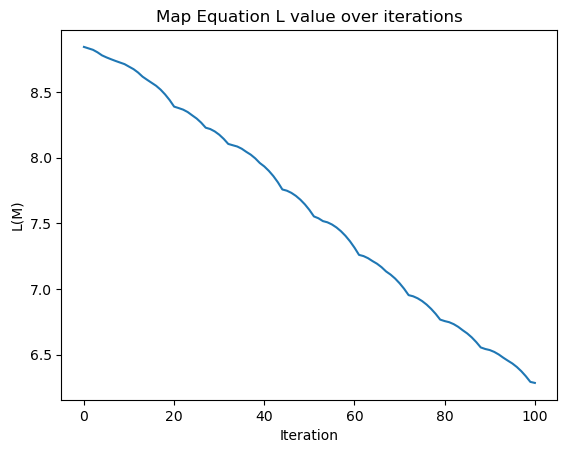

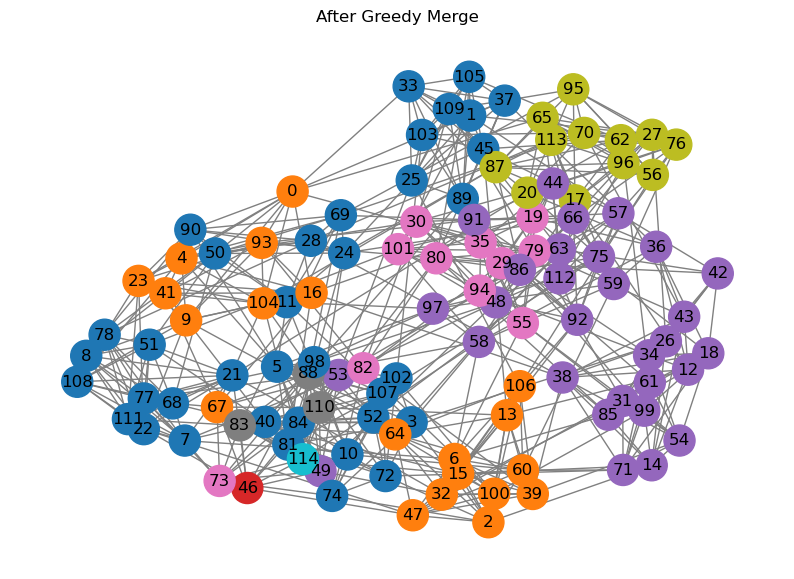

In [67]:
G = nx.read_gml("./network/football.gml")
G = nx.convert_node_labels_to_integers(G)
greedy_partition, L_history = greedyMerge(G, n_iter=100, save_history=True)

print("Final partitions: m =", len(set(greedy_partition.values())))
print(f"After greedy search: L = {L_history[-1]:.4f} bits")

plt.plot(L_history)
plt.xlabel('Iteration')
plt.ylabel('L(M)')
plt.title('Map Equation L value over iterations')
plt.show()

draw_partition(G, greedy_partition, title="After Greedy Merge")

Final partitions: m = 11
After simulated annealing: L = 5.9668 bits


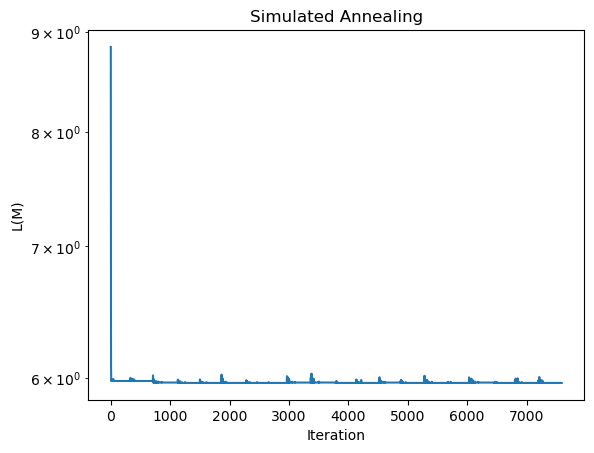

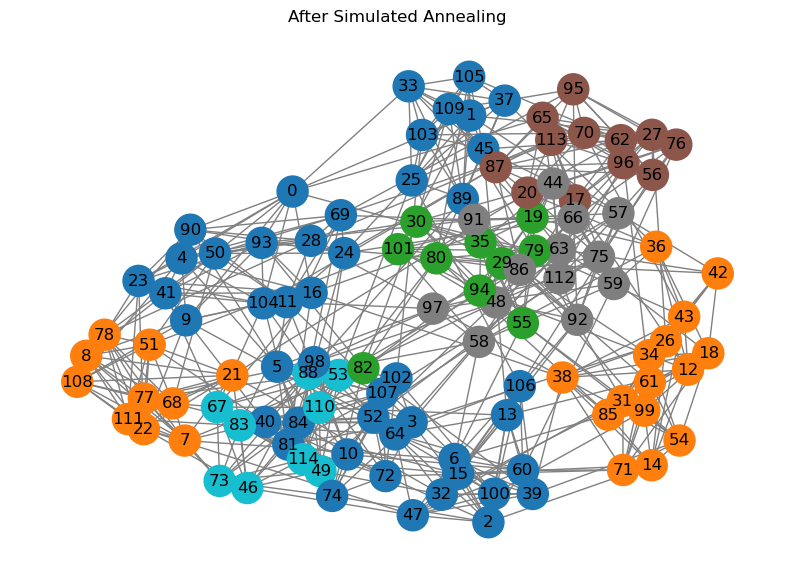

In [72]:
probs = list(nx.pagerank(G).values())
random_partition = {u: u for u in G.nodes()}
final_partition, L_history_sa = coolingCycles(G, random_partition, probs, tau=0.15, cooling_cycles=20, save_history=True,
                                              T_max=0.005, T_min=1e-4, cooling_rate=0.99, n_iter=200)

print("Final partitions: m =", len(set(final_partition.values())))
print(f"After simulated annealing: L = {mapEquation(G, final_partition, probs, tau=0.15):.4f} bits")

plt.plot(L_history_sa)
plt.xlabel('Iteration')
plt.ylabel('L(M)')
plt.title('Simulated Annealing')
plt.yscale('log')
plt.show()

draw_partition(G, final_partition, title="After Simulated Annealing")

In [73]:
from sklearn.metrics import normalized_mutual_info_score

ground_truth = {n: G.nodes[n]['value'] for n in G.nodes()}
nodes_sorted = sorted(G.nodes())

list_ground_truth = [ground_truth[n] for n in nodes_sorted]
list_greedy       = [greedy_partition[n] for n in nodes_sorted]
list_annealing    = [final_partition[n] for n in nodes_sorted]

nmi_annealing = normalized_mutual_info_score(list_ground_truth, list_annealing)
nmi_greedy = normalized_mutual_info_score(list_ground_truth, list_greedy)

print(f"NMI (ground truth -- greedy): {nmi_greedy:.4f}")
print(f"NMI (ground truth -- after annealing): {nmi_annealing:.4f}")

NMI (ground truth -- greedy): 0.8203
NMI (ground truth -- after annealing): 0.9114
